# Credit Card Fraud Detection — ANN

**Dataset:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense



In [17]:
df = pd.read_csv('creditcard.csv')

In [18]:



print("Shape:", df.shape)
print("Fraud cases:", df['Class'].sum())
print("Normal cases:", len(df) - df['Class'].sum())
df.head()

Shape: (284807, 31)
Fraud cases: 492
Normal cases: 284315


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Enhanced Exploratory Data Analysis (EDA)
In this section, we add more visualizations using Seaborn to better understand the data distribution and relationships between features.

In [ ]:
import seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline

### 1. Class Distribution
Visualizing the imbalance in the dataset.

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Distribution of Fraudulent vs Normal Transactions')
plt.yscale('log') # Log scale to see the minority class clearly
plt.show()

### 2. Feature Correlation
Checking how features correlate with the target class.

In [ ]:
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

### 3. Distribution of Time and Amount
Analyzing the two non-anonymized features.

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(df['Time'], bins=50, kde=True, ax=ax[0], color='blue')
ax[0].set_title('Distribution of Transaction Time')

sns.histplot(df['Amount'], bins=50, kde=True, ax=ax[1], color='red')
ax[1].set_title('Distribution of Transaction Amount')
ax[1].set_yscale('log')

plt.show()

### 4. Comparison of V-Features (V1-V4)
Looking at the distribution of some PCA-transformed features for Fraud vs Normal.

In [ ]:
v_features = ['V1', 'V2', 'V3', 'V4']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(v_features):
    sns.boxplot(x='Class', y=feature, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution of {feature} by Class')

plt.tight_layout()
plt.show()

### 5. Time vs Amount Scatter Plot
Exploring if there's a pattern between time and amount for fraud cases.

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Time', y='Amount', hue='Class', data=df, alpha=0.5, palette='coolwarm')
plt.title('Time vs Amount by Class')
plt.show()

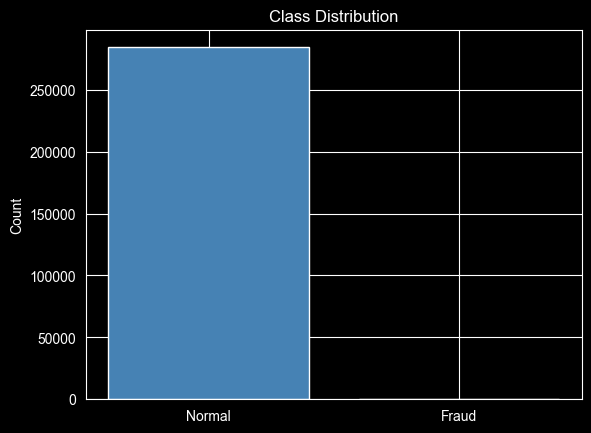

In [19]:
# CLASS BALANCE
counts = df['Class'].value_counts()
plt.bar(['Normal', 'Fraud'], counts.values, color=['steelblue', 'tomato'])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()


In [20]:

# Scale Amount and Time (V1-V28 are already scaled)
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time']   = scaler.fit_transform(df[['Time']])


In [21]:
# Balance dataset: all 492 fraud + 2460 normal (5x)
fraud  = df[df['Class'] == 1]
normal = df[df['Class'] == 0].sample(n=len(fraud) * 5, random_state=42)
data   = pd.concat([fraud, normal]).sample(frac=1, random_state=42)

In [22]:

X = data.drop('Class', axis=1).values
y = data['Class'].values

In [23]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (2361, 30)
Test size:  (591, 30)


In [25]:

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\ammar\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8633 - loss: 0.4922 - val_accuracy: 0.9662 - val_loss: 0.2633
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9624 - loss: 0.2252 - val_accuracy: 0.9683 - val_loss: 0.1488
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9645 - loss: 0.1565 - val_accuracy: 0.9746 - val_loss: 0.1036
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9677 - loss: 0.1255 - val_accuracy: 0.9810 - val_loss: 0.0845
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9714 - loss: 0.1083 - val_accuracy: 0.9831 - val_loss: 0.0768
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9730 - loss: 0.0981 - val_accuracy: 0.9810 - val_loss: 0.0727
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9746 - loss: 0.0907 - val_accuracy: 0.9810 - val_loss: 0.0717
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9751 - loss: 0.0862 - val_accuracy: 0.9789 - val_loss:

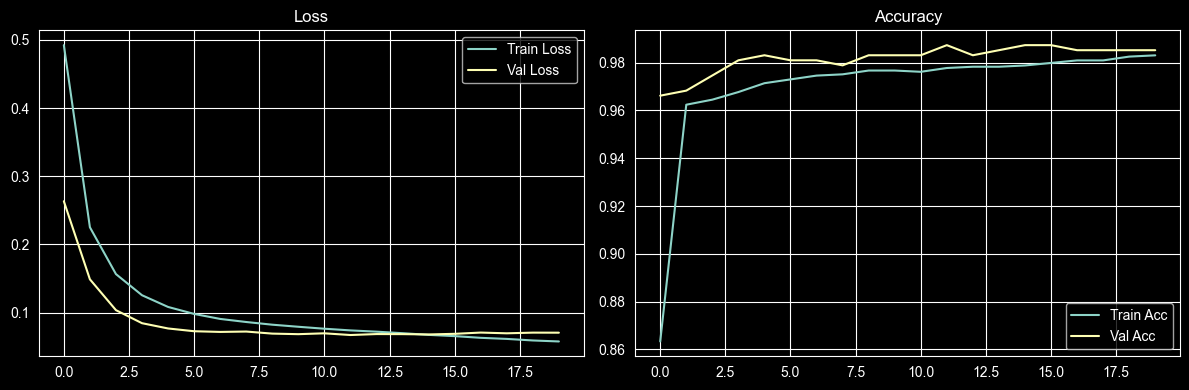

In [27]:

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98       482
       Fraud       0.95      0.90      0.92       109

    accuracy                           0.97       591
   macro avg       0.96      0.94      0.95       591
weighted avg       0.97      0.97      0.97       591

Confusion Matrix:
[[477   5]
 [ 11  98]]


### 6. Addressing Class Imbalance
Since the dataset is highly imbalanced, we will perform a simple under-sampling to balance the classes for better model training.

In [ ]:
# Number of fraud cases
fraud_count = len(df[df['Class'] == 1])
fraud_indices = df[df['Class'] == 1].index

# Randomly select normal cases equal to fraud cases
normal_indices = df[df['Class'] == 0].index
random_normal_indices = np.random.choice(normal_indices, fraud_count, replace=False)

# Combine indices
under_sample_indices = np.concatenate([fraud_indices, random_normal_indices])

# Create under-sampled dataframe
df_balanced = df.iloc[under_sample_indices]

print("New distribution:")
print(df_balanced['Class'].value_counts())

### 7. Enhanced Model Evaluation
Adding ROC-AUC curve to evaluate the model performance more comprehensively.

In [ ]:
from sklearn.metrics import roc_curve, auc

# Note: This cell assumes 'model' and 'X_test', 'y_test' exist from the original code
# We will place this at the end of the notebook.
def plot_roc_curve(y_true, y_pred_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

### 8. Violin Plots for Key Features
Violin plots combine box plots and density plots to show the distribution of features more clearly.

In [ ]:
# Choosing some highly correlated features with Class
key_v_features = ['V17', 'V14', 'V12', 'V10']
plt.figure(figsize=(16, 10))
for i, col in enumerate(key_v_features):
    plt.subplot(2, 2, i+1)
    sns.violinplot(x='Class', y=col, data=df, palette='muted')
    plt.title(f'Violin Plot of {col} by Class')
plt.tight_layout()
plt.show()

### 9. Joint Plot for Time vs Amount
Exploring the joint distribution of Time and Amount for Fraudulent transactions.

In [ ]:
fraud_df = df[df['Class'] == 1]
sns.jointplot(x='Time', y='Amount', data=fraud_df, kind='hex', color='red')
plt.suptitle('Joint Distribution of Time and Amount for Fraud', y=1.02)
plt.show()

### 10. KDE Plots for Feature Overlap
Kernel Density Estimate plots help visualize where the Fraud and Normal distributions overlap.

In [ ]:
plt.figure(figsize=(12, 6))
sns.kdeplot(df[df['Class'] == 0]['V14'], label='Normal', fill=True)
sns.kdeplot(df[df['Class'] == 1]['V14'], label='Fraud', fill=True)
plt.title('KDE Plot of V14: Normal vs Fraud')
plt.legend()
plt.show()

### 11. Pair Plot of Top Features
Visualizing pairwise relationships between a subset of important features.

In [ ]:
# Using the balanced dataframe from previous step for pairplot to keep it fast
top_features = ['V17', 'V14', 'V12', 'Class']
sns.pairplot(df_balanced[top_features], hue='Class', palette='husl')
plt.suptitle('Pair Plot of Top Correlated Features', y=1.02)
plt.show()